# Installation

Install required Python packages for FinRL trading environment.

In [15]:
!pip install -q exchange-calendars finrl yfinance
!pip install -q stable-baselines3[extra] shap stockstats
!pip install -q pyfolio-reloaded gymnasium wrds
!pip install -q alpaca-trade-api
!pip install -q deprecation websocket-client

%matplotlib inline

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
yfinance 0.2.66 requires websockets>=13.0, but you have websockets 10.4 which is incompatible.


# Imports

Load essential libraries for data processing, visualization, reinforcement learning, and explainability.

In [16]:
import os

# Create project folders for saving results locally
PROJECT_PATH = './FinRL_Trading_Results'
os.makedirs(PROJECT_PATH, exist_ok=True)
os.makedirs(f'{PROJECT_PATH}/checkpoints', exist_ok=True)
os.makedirs(f'{PROJECT_PATH}/plots', exist_ok=True)

print(f"Project directory created: {PROJECT_PATH}")

Project directory created: ./FinRL_Trading_Results


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import warnings
warnings.filterwarnings('ignore')

from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer, data_split
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl import config_tickers
from finrl.config import INDICATORS

from stable_baselines3 import PPO, A2C
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.vec_env import VecNormalize
import shap
import yfinance as yf

# Configuration

Define trading parameters including date ranges, ticker symbols, technical indicators, and portfolio settings.

In [18]:
TRAIN_START_DATE = '2016-01-01'
TRAIN_END_DATE = '2023-01-01'
TEST_START_DATE = '2023-01-01'
TEST_END_DATE = '2025-01-01'

TICKER_LIST = [
    # Green Energy
    "NEE", "FSLR", "BEP", "PLUG",

    # Oil & Gas
    "XOM", "CVX", "COP", "SLB",

    # Banking & Finance
    "JPM", "BAC", "WFC", "GS", "MS",

    # Utilities / General Energy
    "DUK", "SO", "PCG", "EIX",

    # IT / Tech
    "AAPL", "MSFT", "GOOGL", "NVDA", "AMZN", "META", "ORCL", "IBM"
]

INDICATORS_LIST = ['macd', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma', 'close_60_sma']

INITIAL_AMOUNT = 100000
TRANSACTION_COST_PCT = 0.001
REWARD_SCALING = 1e-4

# Patch Yahoo Downloader

Custom data fetching function to handle multi-ticker downloads with proper column formatting.

In [19]:
def safe_fetch_data(self):
    data = yf.download(
        tickers=self.ticker_list,
        start=self.start_date,
        end=self.end_date,
        auto_adjust=False,
        progress=True,
        threads=True,
    )

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = ['_'.join([str(c) for c in col]).strip() for col in data.columns.values]

    allowed = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
    data = data[[col for col in data.columns if any(a in col for a in allowed)]]
    data.reset_index(inplace=True)
    return data

YahooDownloader.fetch_data = safe_fetch_data

# Download Market Data

Fetch historical OHLCV data from Yahoo Finance for the selected tickers.

In [20]:
df = YahooDownloader(
    start_date=TRAIN_START_DATE,
    end_date=TEST_END_DATE,
    ticker_list=TICKER_LIST
).fetch_data()

print(f"Downloaded {len(df)} rows | Date range: {df['Date'].min()} to {df['Date'].max()}")
display(df.head())

[*********************100%***********************]  25 of 25 completed



Downloaded 2264 rows | Date range: 2016-01-04 00:00:00 to 2024-12-31 00:00:00


,Date,Adj Close_AAPL,Adj Close_AMZN,Adj Close_BAC,Adj Close_BEP,Adj Close_COP,Adj Close_CVX,Adj Close_DUK,Adj Close_EIX,Adj Close_FSLR,...,Volume_MSFT,Volume_NEE,Volume_NVDA,Volume_ORCL,Volume_PCG,Volume_PLUG,Volume_SLB,Volume_SO,Volume_WFC,Volume_XOM
0,2016-01-04,23.753151,31.849501,13.265053,8.226594,34.492241,57.923458,47.192829,39.576000,66.720001,...,53778000,7716400,358076000,18784400,2201500,2373300,9160200,6946500,25985400,20400100
1,2016-01-05,23.157917,31.689501,13.265053,8.300943,34.874821,58.418922,47.530914,39.589432,72.029999,...,34079700,8915200,490272000,25340700,2345700,957100,6783600,5830900,14759600,11993500
2,2016-01-06,22.704721,31.632500,12.982471,8.187806,33.366520,56.111126,47.636967,39.327610,69.519997,...,39518900,6983200,449344000,18165700,2599300,1672700,11923000,5868700,20026400,18826900
3,2016-01-07,21.746481,30.396999,12.514199,7.738495,32.417404,54.122746,47.199448,39.132915,66.220001,...,56564900,12870800,645304000,22591400,2331100,2754300,12041000,5837700,30425600,21263800
4,2016-01-08,21.861462,30.352501,12.271991,7.625359,31.850872,53.542503,47.093395,39.126198,65.620003,...,48754000,14382000,398472000,21962200,3351500,1611400,9657900,5220200,22981400,19033600


# Process Data

Convert wide-format data to FinRL-compatible long format with standardized column names.

In [21]:
def make_finrl_ready(df, tickers):
    """Convert raw Yahoo data to FinRL long-format DataFrame."""
    df = df.copy()

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = ['_'.join([str(c) for c in col if c]).strip() for col in df.columns.values]
        df = df.reset_index()
    else:
        df = df.reset_index() if 'Date' not in df.columns and 'date' not in df.columns else df

    if 'Date' in df.columns:
        df.rename(columns={'Date': 'date'}, inplace=True)
    df['date'] = pd.to_datetime(df['date'])

    if len(tickers) == 1:
        ticker = tickers[0]
        df_long = df.rename(columns={
            f'Open_{ticker}': 'open', f'High_{ticker}': 'high', f'Low_{ticker}': 'low',
            f'Close_{ticker}': 'close', f'Adj Close_{ticker}': 'adj_close', f'Volume_{ticker}': 'volume'
        })
        df_long['tic'] = ticker
    else:
        df_long = pd.DataFrame()
        for ticker in tickers:
            ticker_cols = [c for c in df.columns if c.endswith(f'_{ticker}')]
            temp = df[['date'] + ticker_cols].copy()
            col_map = {c: c.replace(f'_{ticker}','').lower().replace(' ','_') for c in ticker_cols}
            temp.rename(columns=col_map, inplace=True)
            temp['tic'] = ticker
            df_long = pd.concat([df_long, temp], ignore_index=True)

    required_cols = ['date', 'tic', 'open', 'high', 'low', 'close', 'adj_close', 'volume']
    return df_long[required_cols]

df_finrl = make_finrl_ready(df, TICKER_LIST)
print(f"Processed shape: {df_finrl.shape}")

Processed shape: (56600, 8)


# Feature Engineering

Generate technical indicators (MACD, RSI, CCI, DX, SMA) to enrich the state space for the RL agent.

In [22]:
fe = FeatureEngineer(
    use_technical_indicator=True,
    tech_indicator_list=INDICATORS_LIST,
    use_vix=False,
    use_turbulence=False,
    user_defined_feature=False
)

processed_df = fe.preprocess_data(df_finrl).dropna()
print(f"Features added: {INDICATORS_LIST}")
display(processed_df.head())

Successfully added technical indicators
Features added: ['macd', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma', 'close_60_sma']


,date,tic,open,high,low,close,adj_close,volume,macd,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma
0,2016-01-04,AAPL,25.652500,26.342501,25.500000,26.337500,23.753151,270597600,0.0,0.0,-66.666667,100.0,26.337500,26.337500
2264,2016-01-04,AMZN,32.814499,32.886002,31.375500,31.849501,31.849501,186290000,0.0,0.0,-66.666667,100.0,31.849501,31.849501
4528,2016-01-04,BAC,16.450001,16.490000,16.250000,16.430000,13.265053,114888000,0.0,0.0,-66.666667,100.0,16.430000,16.430000
6792,2016-01-04,BEP,13.930189,13.930189,13.471889,13.562483,8.226594,60048,0.0,0.0,-66.666667,100.0,13.562483,13.562483
9056,2016-01-04,COP,46.410000,47.770000,46.080002,46.880001,34.492241,8918000,0.0,0.0,-66.666667,100.0,46.880001,46.880001


# Train/Test Split

Split data into training (2019-2023) and testing (2023-2025) periods.

In [23]:
train_df = data_split(processed_df, TRAIN_START_DATE, TRAIN_END_DATE)
test_df = data_split(processed_df, TEST_START_DATE, TEST_END_DATE)

print(f"Training: {len(train_df)} samples ({TRAIN_START_DATE} to {TRAIN_END_DATE})")
print(f"Testing:  {len(test_df)} samples ({TEST_START_DATE} to {TEST_END_DATE})")

Training: 44050 samples (2016-01-01 to 2023-01-01)
Testing:  12550 samples (2023-01-01 to 2025-01-01)


# Create Training Environment

Initialize the stock trading environment with the configured state space and action space.

In [24]:
stock_dimension = len(train_df.tic.unique())
state_space = 1 + 2*stock_dimension + len(INDICATORS_LIST)*stock_dimension

env_kwargs = {
    "hmax": 100,
    "initial_amount": INITIAL_AMOUNT,
    "num_stock_shares": [0] * stock_dimension,
    "buy_cost_pct": [TRANSACTION_COST_PCT] * stock_dimension,
    "sell_cost_pct": [TRANSACTION_COST_PCT] * stock_dimension,
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "tech_indicator_list": INDICATORS_LIST,
    "action_space": stock_dimension,
    "reward_scaling": REWARD_SCALING
}

train_env = DummyVecEnv([lambda: StockTradingEnv(df=train_df, **env_kwargs)])
train_env = VecNormalize(train_env, norm_obs=True, norm_reward=True, gamma=0.99)
print(f"Stocks: {stock_dimension} | State space: {state_space} | Action space: {stock_dimension}")

Stocks: 25 | State space: 201 | Action space: 25


# Train PPO Model

Train a Proximal Policy Optimization (PPO) agent to learn optimal trading strategies and save checkpoint.

In [27]:
from datetime import datetime


model = PPO(
    "MlpPolicy",
    train_env,
    learning_rate=0.00003,
    n_steps=512,
    batch_size=256,
    n_epochs=10,
    gamma=0.99,
    ent_coef=0.005,
    gae_lambda=0.95,
    clip_range=0.2,
    verbose=1
)

TOTAL_TIMESTEPS = 1000000
model.learn(total_timesteps=TOTAL_TIMESTEPS)

# Save checkpoint after training
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
checkpoint_path = f"{PROJECT_PATH}/checkpoints/ppo_model_trained_{timestamp}"
model.save(checkpoint_path)

print(f"\n{'='*60}")
print(f"Training completed: {TOTAL_TIMESTEPS:,} timesteps")
print(f"Checkpoint saved: {checkpoint_path}.zip")
print(f"{'='*60}")

Using cuda device
----------------------------
| time/              |     |
|    fps             | 347 |
|    iterations      | 1   |
|    time_elapsed    | 1   |
|    total_timesteps | 512 |
----------------------------
----------------------------
| time/              |     |
|    fps             | 347 |
|    iterations      | 1   |
|    time_elapsed    | 1   |
|    total_timesteps | 512 |
----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 346          |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 1024         |
| train/                  |              |
|    approx_kl            | 0.0004133503 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -35.5        |
|    explained_variance   | -0.433       |
|    learning_rate        | 3e-05        |
|    loss        

# Backtest Model

Evaluate the trained agent on unseen test data and calculate performance metrics.

In [28]:
stock_dimension = len(test_df.tic.unique())
state_space = 1 + 2*stock_dimension + len(INDICATORS_LIST)*stock_dimension

env_kwargs = {
    "hmax": 100,
    "initial_amount": INITIAL_AMOUNT,
    "num_stock_shares": [0] * stock_dimension,
    "buy_cost_pct": [TRANSACTION_COST_PCT] * stock_dimension,
    "sell_cost_pct": [TRANSACTION_COST_PCT] * stock_dimension,
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "tech_indicator_list": INDICATORS_LIST,
    "action_space": stock_dimension,
    "reward_scaling": REWARD_SCALING
}

test_env = StockTradingEnv(df=test_df, **env_kwargs)
test_obs, info = test_env.reset()

account_values, actions_taken, states_log, dates_log = [], [], [], []

done = False
while not done:
    action, _states = model.predict(test_obs, deterministic=True)
    step_result = test_env.step(action)

    if len(step_result) == 5:
        test_obs, rewards, terminated, truncated, info = step_result
        done = terminated or truncated
    else:
        test_obs, rewards, done, info = step_result

    account_values.append(test_env.asset_memory[-1])
    actions_taken.append(action)
    states_log.append(test_obs)

# Calculate metrics
initial_value = INITIAL_AMOUNT
final_value = account_values[-1]
total_return = (final_value - initial_value) / initial_value * 100
returns = pd.Series(account_values).pct_change().dropna()
sharpe_ratio = returns.mean() / returns.std() * np.sqrt(252) if returns.std() != 0 else 0
cumulative = pd.Series(account_values)
max_drawdown = ((cumulative - cumulative.cummax()) / cumulative.cummax()).min() * 100
volatility = returns.std() * np.sqrt(252) * 100
win_rate = (returns > 0).sum() / len(returns) * 100 if len(returns) > 0 else 0

print(f"\n{'='*60}")
print(f"{'BACKTEST RESULTS':^60}")
print(f"{'='*60}")
print(f"Initial Value:     ${initial_value:>15,.2f}")
print(f"Final Value:       ${final_value:>15,.2f}")
print(f"Total Return:      {total_return:>15.2f}%")
print(f"Sharpe Ratio:      {sharpe_ratio:>15.2f}")
print(f"Max Drawdown:      {max_drawdown:>15.2f}%")
print(f"Volatility:        {volatility:>15.2f}%")
print(f"Win Rate:          {win_rate:>15.2f}%")
print(f"{'='*60}")


                      BACKTEST RESULTS                      
Initial Value:     $     100,000.00
Final Value:       $     151,907.57
Total Return:                51.91%
Sharpe Ratio:                 1.31
Max Drawdown:               -12.55%
Volatility:                  17.18%
Win Rate:                    52.89%


# Performance Visualization

Visualize portfolio performance, returns distribution, drawdowns, and trading activity.

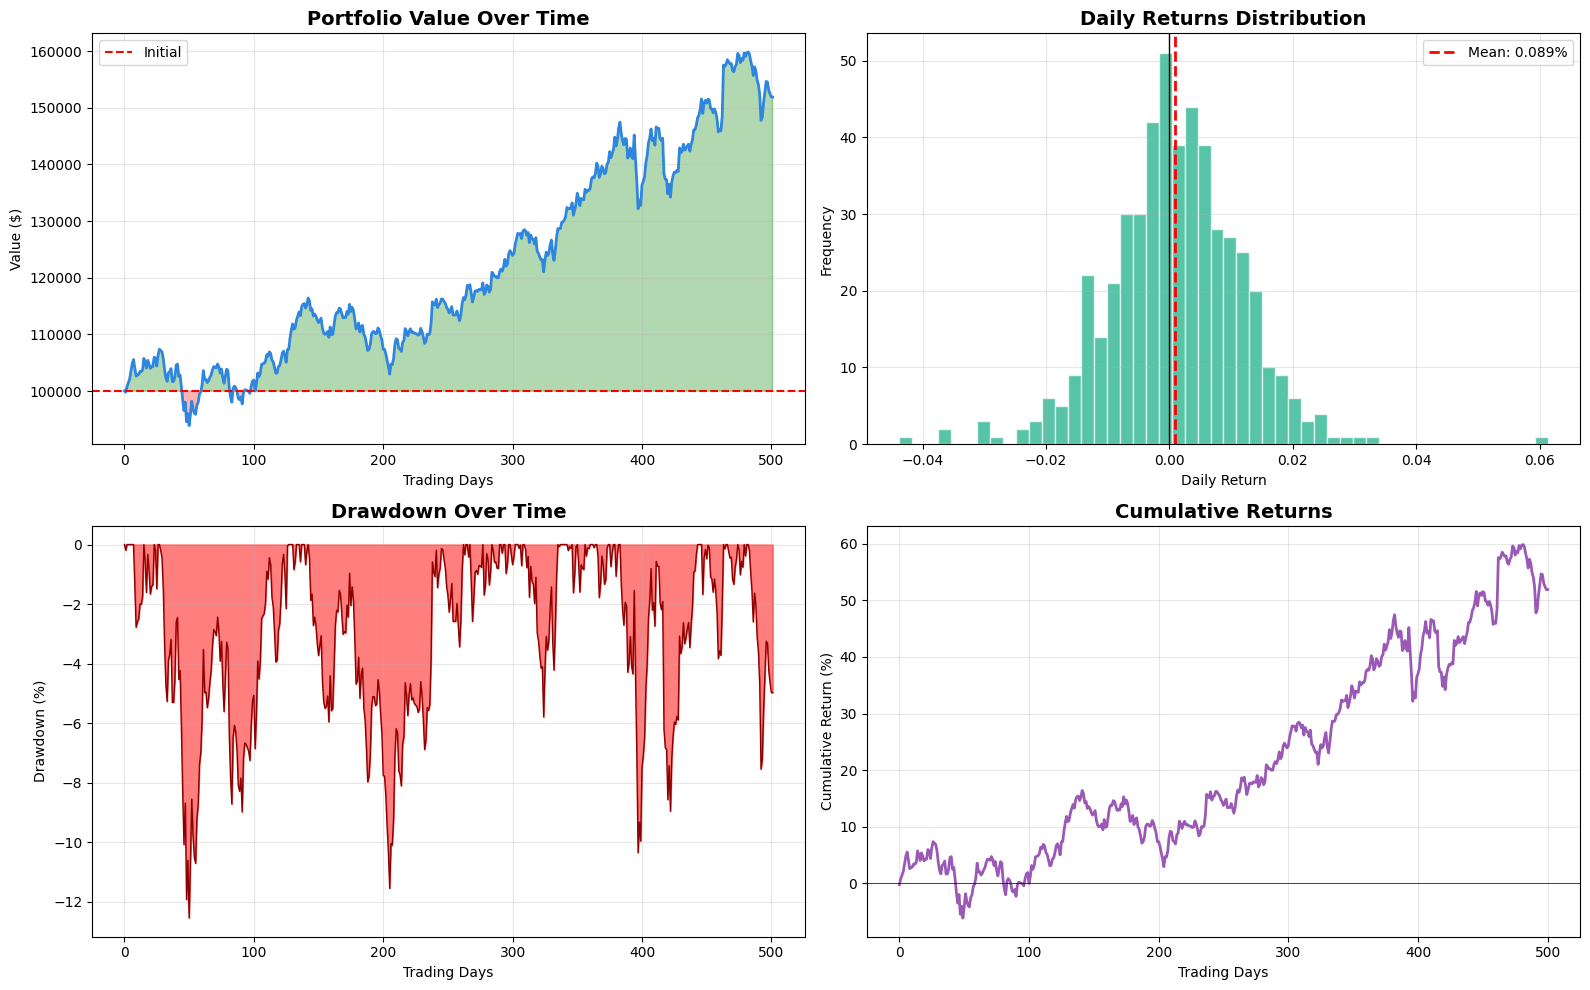

Saved: ./FinRL_Trading_Results/plots/portfolio_performance.png


In [29]:
%matplotlib inline
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Portfolio Value
axes[0,0].plot(account_values, linewidth=2, color='#2E86DE')
axes[0,0].axhline(y=initial_value, color='red', linestyle='--', linewidth=1.5, label='Initial')
axes[0,0].fill_between(range(len(account_values)), initial_value, account_values,
                        where=[v >= initial_value for v in account_values], alpha=0.3, color='green')
axes[0,0].fill_between(range(len(account_values)), initial_value, account_values,
                        where=[v < initial_value for v in account_values], alpha=0.3, color='red')
axes[0,0].set_title('Portfolio Value Over Time', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Trading Days')
axes[0,0].set_ylabel('Value ($)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Daily Returns Distribution
axes[0,1].hist(returns, bins=50, color='#10AC84', edgecolor='white', alpha=0.7)
axes[0,1].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[0,1].axvline(x=returns.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {returns.mean()*100:.3f}%')
axes[0,1].set_title('Daily Returns Distribution', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Daily Return')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Drawdown
drawdown = (cumulative - cumulative.cummax()) / cumulative.cummax() * 100
axes[1,0].fill_between(range(len(drawdown)), 0, drawdown, color='red', alpha=0.5)
axes[1,0].plot(drawdown, color='darkred', linewidth=1)
axes[1,0].set_title('Drawdown Over Time', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Trading Days')
axes[1,0].set_ylabel('Drawdown (%)')
axes[1,0].grid(True, alpha=0.3)

# Cumulative Returns
cumulative_returns = (1 + returns).cumprod() - 1
axes[1,1].plot(cumulative_returns.values * 100, linewidth=2, color='#9B59B6')
axes[1,1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1,1].set_title('Cumulative Returns', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Trading Days')
axes[1,1].set_ylabel('Cumulative Return (%)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/plots/portfolio_performance.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {PROJECT_PATH}/plots/portfolio_performance.png")

# Additional Performance Analysis

Rolling statistics, risk metrics, action distribution, and benchmark comparison.

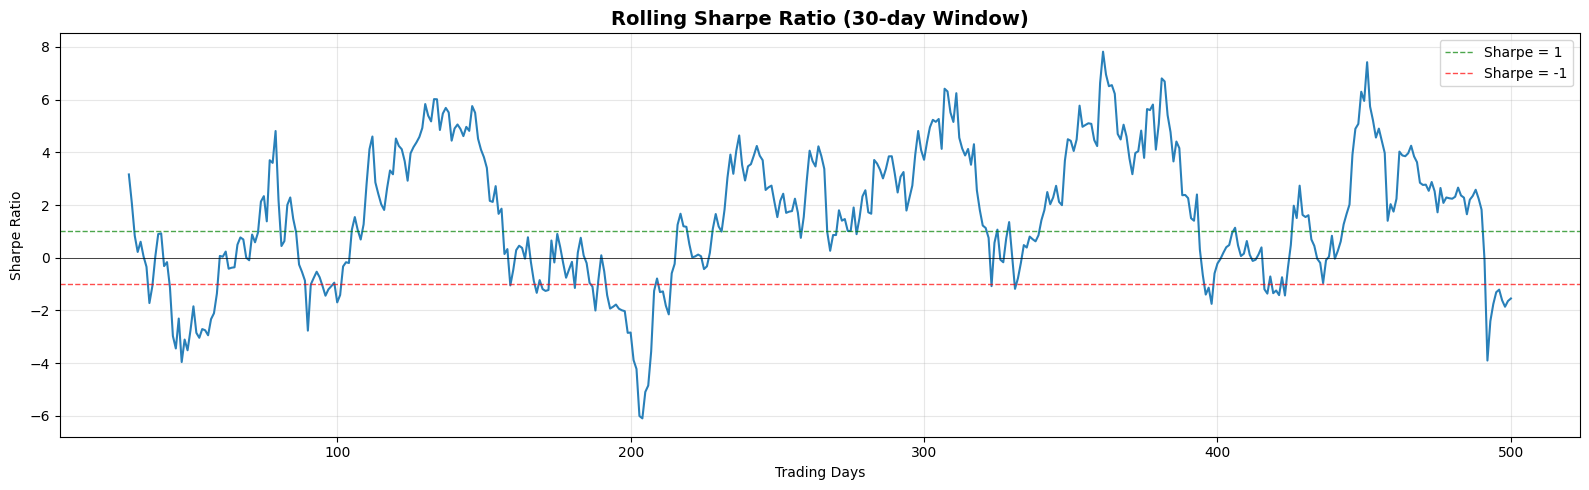

Saved: ./FinRL_Trading_Results/plots/rolling_sharpe.png


In [30]:
# Rolling Sharpe Ratio (30-day window)
window = 30
rolling_returns = returns.rolling(window=window)
rolling_sharpe = (rolling_returns.mean() / rolling_returns.std()) * np.sqrt(252)

plt.figure(figsize=(16, 5))
plt.plot(rolling_sharpe.values, linewidth=1.5, color='#2980B9')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.axhline(y=1, color='green', linestyle='--', linewidth=1, alpha=0.7, label='Sharpe = 1')
plt.axhline(y=-1, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Sharpe = -1')
plt.title(f'Rolling Sharpe Ratio ({window}-day Window)', fontsize=14, fontweight='bold')
plt.xlabel('Trading Days')
plt.ylabel('Sharpe Ratio')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/plots/rolling_sharpe.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {PROJECT_PATH}/plots/rolling_sharpe.png")

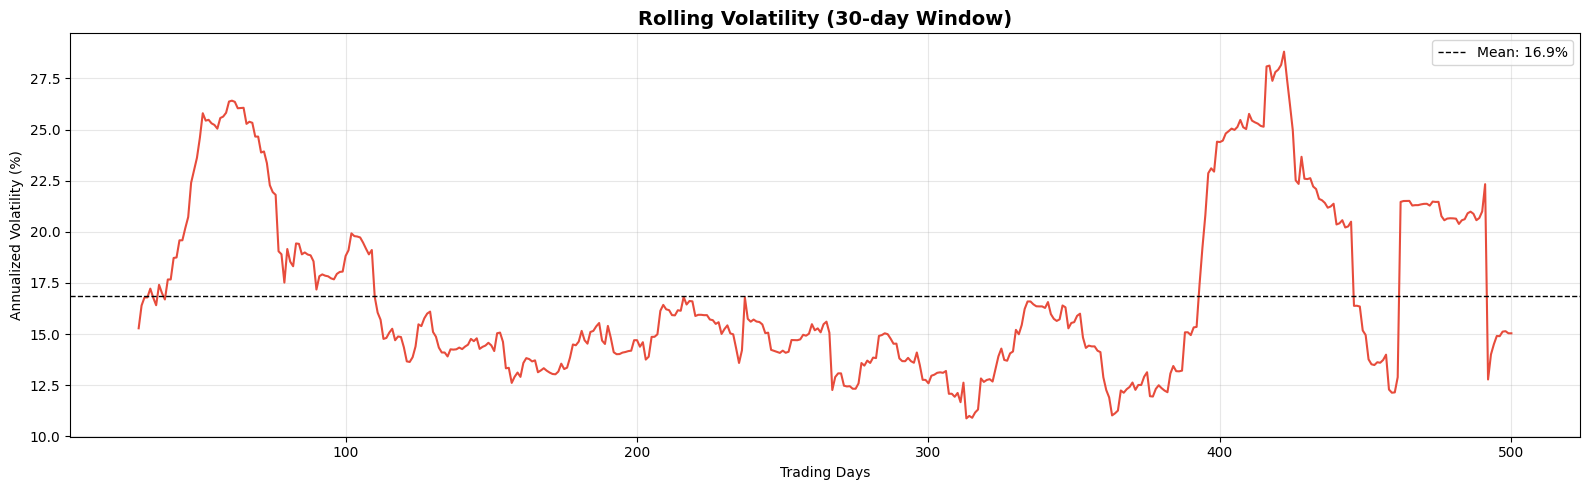

Saved: ./FinRL_Trading_Results/plots/rolling_volatility.png


In [31]:
# Rolling Volatility
rolling_vol = returns.rolling(window=window).std() * np.sqrt(252) * 100

plt.figure(figsize=(16, 5))
plt.plot(rolling_vol.values, linewidth=1.5, color='#E74C3C')
plt.axhline(y=rolling_vol.mean(), color='black', linestyle='--', linewidth=1, label=f'Mean: {rolling_vol.mean():.1f}%')
plt.title(f'Rolling Volatility ({window}-day Window)', fontsize=14, fontweight='bold')
plt.xlabel('Trading Days')
plt.ylabel('Annualized Volatility (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/plots/rolling_volatility.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {PROJECT_PATH}/plots/rolling_volatility.png")

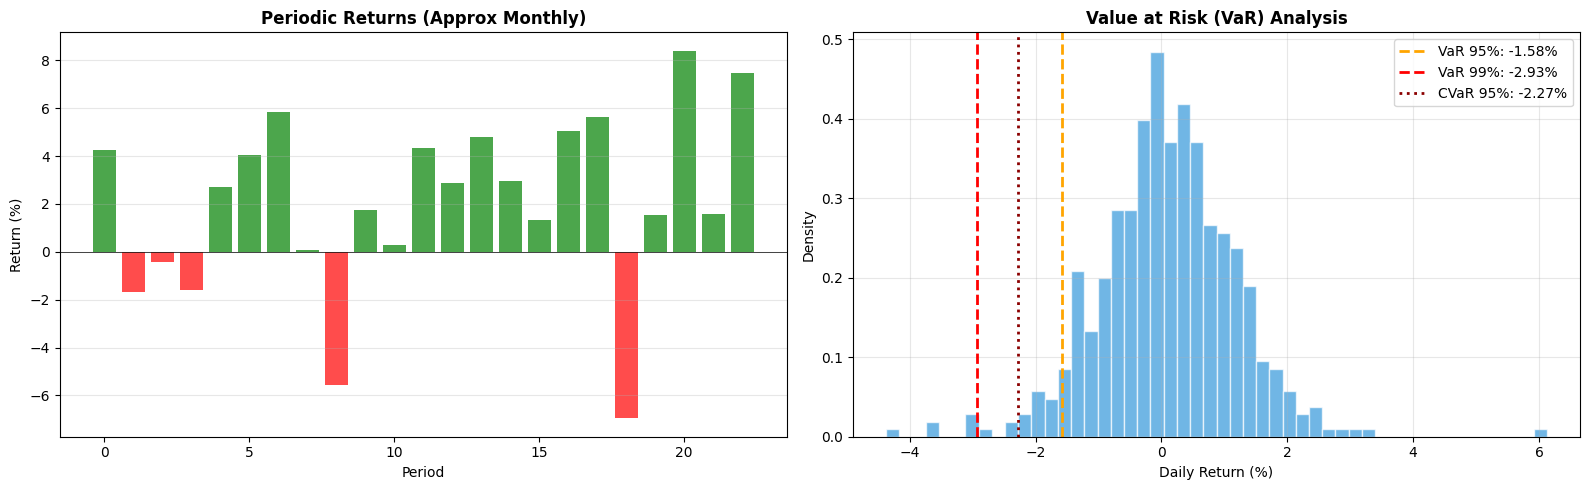

Saved: ./FinRL_Trading_Results/plots/periodic_var.png


In [32]:
# Periodic Returns (Monthly-like) and Value at Risk
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Monthly returns bar chart
monthly_values = pd.Series(account_values)
monthly_returns_pct = monthly_values.pct_change().dropna()
period_size = 21
n_periods = len(monthly_returns_pct) // period_size
period_returns = []
for i in range(n_periods):
    start_idx = i * period_size
    end_idx = (i + 1) * period_size
    period_ret = (1 + monthly_returns_pct.iloc[start_idx:end_idx]).prod() - 1
    period_returns.append(period_ret * 100)

colors = ['green' if r > 0 else 'red' for r in period_returns]
axes[0].bar(range(len(period_returns)), period_returns, color=colors, alpha=0.7)
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].set_title('Periodic Returns (Approx Monthly)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Period')
axes[0].set_ylabel('Return (%)')
axes[0].grid(True, alpha=0.3, axis='y')

# Value at Risk
var_95 = np.percentile(returns, 5) * 100
var_99 = np.percentile(returns, 1) * 100
cvar_95 = returns[returns <= np.percentile(returns, 5)].mean() * 100

axes[1].hist(returns * 100, bins=50, color='#3498DB', edgecolor='white', alpha=0.7, density=True)
axes[1].axvline(x=var_95, color='orange', linestyle='--', linewidth=2, label=f'VaR 95%: {var_95:.2f}%')
axes[1].axvline(x=var_99, color='red', linestyle='--', linewidth=2, label=f'VaR 99%: {var_99:.2f}%')
axes[1].axvline(x=cvar_95, color='darkred', linestyle=':', linewidth=2, label=f'CVaR 95%: {cvar_95:.2f}%')
axes[1].set_title('Value at Risk (VaR) Analysis', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Daily Return (%)')
axes[1].set_ylabel('Density')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/plots/periodic_var.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {PROJECT_PATH}/plots/periodic_var.png")

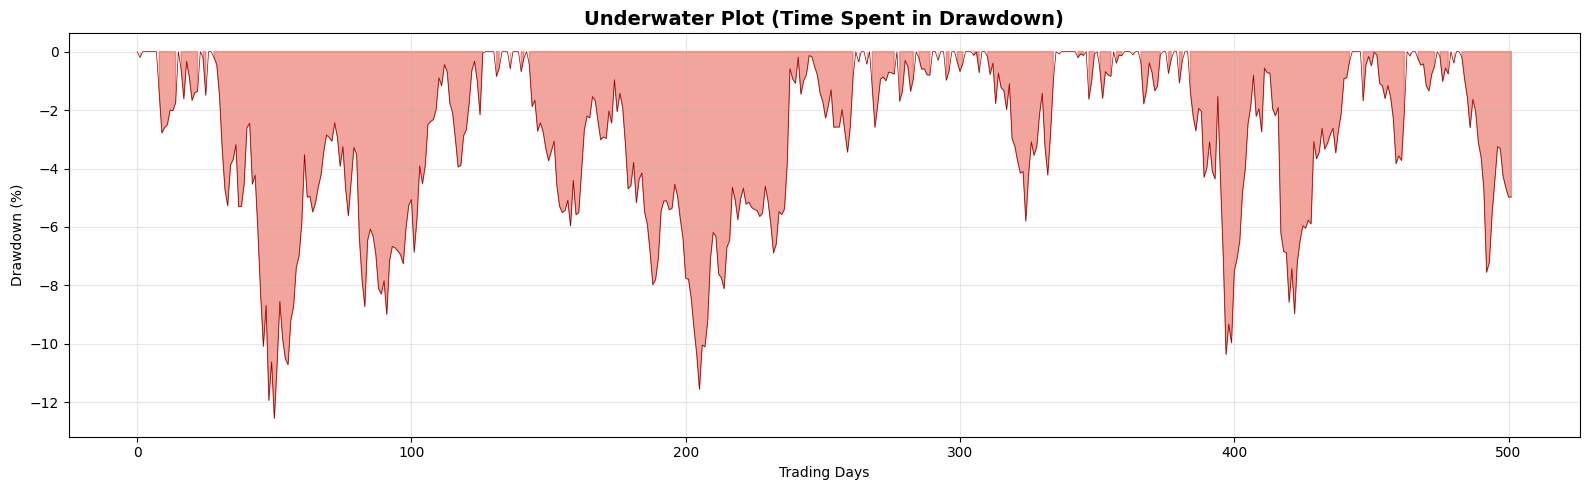

Saved: ./FinRL_Trading_Results/plots/underwater.png


In [33]:
# Underwater Plot (Time in Drawdown)
underwater = (cumulative - cumulative.cummax()) / cumulative.cummax() * 100

plt.figure(figsize=(16, 5))
plt.fill_between(range(len(underwater)), 0, underwater,
                 where=underwater < 0, color='#E74C3C', alpha=0.5)
plt.plot(underwater, color='darkred', linewidth=0.5)
plt.title('Underwater Plot (Time Spent in Drawdown)', fontsize=14, fontweight='bold')
plt.xlabel('Trading Days')
plt.ylabel('Drawdown (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/plots/underwater.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {PROJECT_PATH}/plots/underwater.png")

# Benchmark Comparison and Risk-Adjusted Metrics

Compare portfolio performance against buy-and-hold strategy and market benchmark.

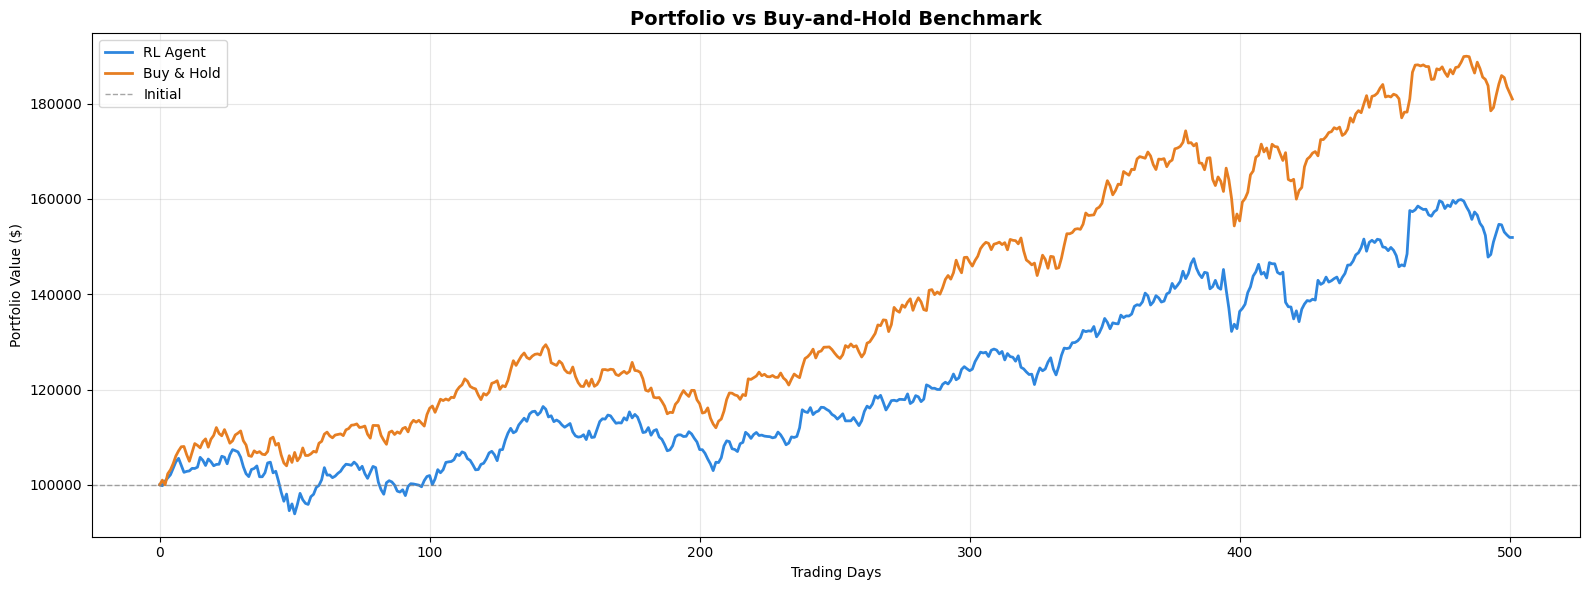

Saved: ./FinRL_Trading_Results/plots/portfolio_vs_benchmark.png


In [34]:
# Calculate buy-and-hold benchmark for each stock
# This ensures we only use tickers that have complete data in test_prices
test_prices = test_df.pivot(index='date', columns='tic', values='close').dropna()

# --- FIX: Use the actual available tickers ---
# Get the list of tickers that survived the data cleaning (dropna())
actual_tickers = test_prices.columns.tolist()

n_trading_days = min(len(account_values), len(test_prices))

# Check if there are any tickers left to calculate a benchmark
if not actual_tickers:
    print("Warning: No tickers found in test_prices after dropping NaNs. Cannot calculate benchmark.")
else:
    # Equal-weight buy and hold
    # The initial amount is divided only among the *actual* available tickers
    initial_per_stock = INITIAL_AMOUNT / len(actual_tickers)

    # Calculate shares bought for each available ticker
    shares_bought = {
        ticker: initial_per_stock / test_prices[ticker].iloc[0]
        for ticker in actual_tickers
    }

    benchmark_values = []
    for i in range(n_trading_days):
        if i < len(test_prices):
            # Calculate the daily value using only the shares and prices of available tickers
            daily_value = sum(shares_bought[ticker] * test_prices[ticker].iloc[i]
                              for ticker in actual_tickers)
            benchmark_values.append(daily_value)

    # Align lengths
    min_len = min(len(account_values), len(benchmark_values))
    portfolio_aligned = account_values[:min_len]
    benchmark_aligned = benchmark_values[:min_len]

    # Plot 1: Portfolio vs Benchmark
    plt.figure(figsize=(16, 6))
    plt.plot(portfolio_aligned, linewidth=2, color='#2E86DE', label='RL Agent')
    plt.plot(benchmark_aligned, linewidth=2, color='#E67E22', label='Buy & Hold')
    plt.axhline(y=INITIAL_AMOUNT, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Initial')
    plt.title('Portfolio vs Buy-and-Hold Benchmark', fontsize=14, fontweight='bold')
    plt.xlabel('Trading Days')
    plt.ylabel('Portfolio Value ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{PROJECT_PATH}/plots/portfolio_vs_benchmark.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved: {PROJECT_PATH}/plots/portfolio_vs_benchmark.png")

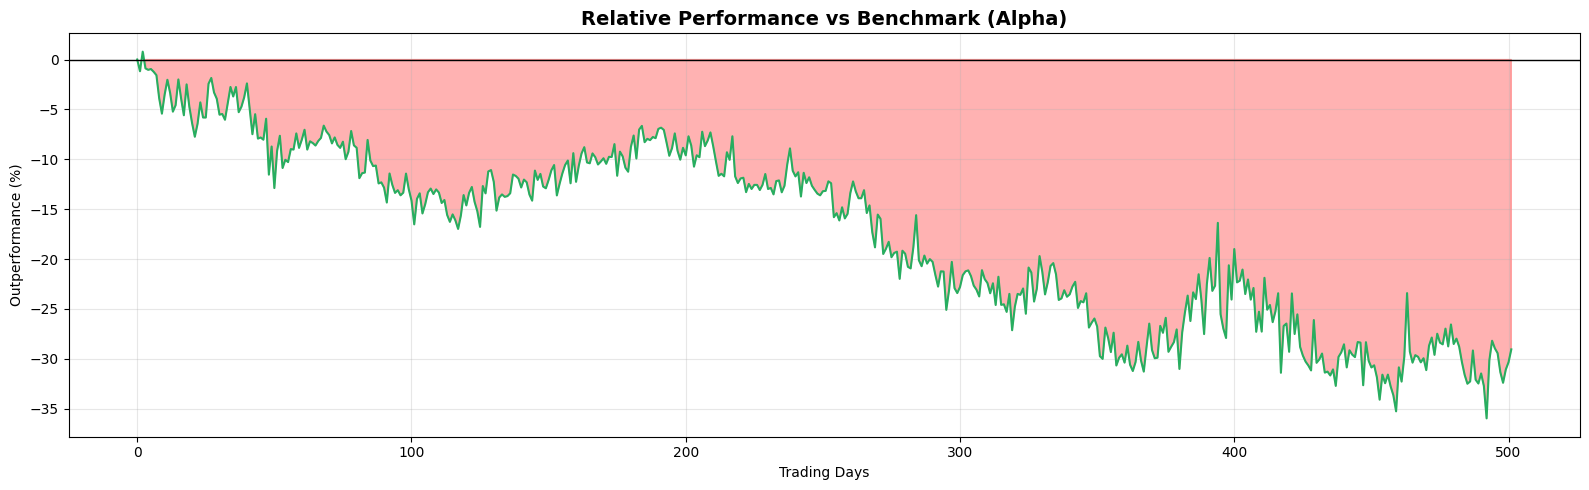

Saved: ./FinRL_Trading_Results/plots/relative_performance.png


In [35]:
# Plot 2: Relative Performance (Alpha)
relative_perf = [(p - b) / INITIAL_AMOUNT * 100 for p, b in zip(portfolio_aligned, benchmark_aligned)]

plt.figure(figsize=(16, 5))
plt.plot(relative_perf, linewidth=1.5, color='#27AE60')
plt.fill_between(range(len(relative_perf)), 0, relative_perf,
                 where=[r >= 0 for r in relative_perf], alpha=0.3, color='green')
plt.fill_between(range(len(relative_perf)), 0, relative_perf,
                 where=[r < 0 for r in relative_perf], alpha=0.3, color='red')
plt.axhline(y=0, color='black', linewidth=1)
plt.title('Relative Performance vs Benchmark (Alpha)', fontsize=14, fontweight='bold')
plt.xlabel('Trading Days')
plt.ylabel('Outperformance (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/plots/relative_performance.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {PROJECT_PATH}/plots/relative_performance.png")

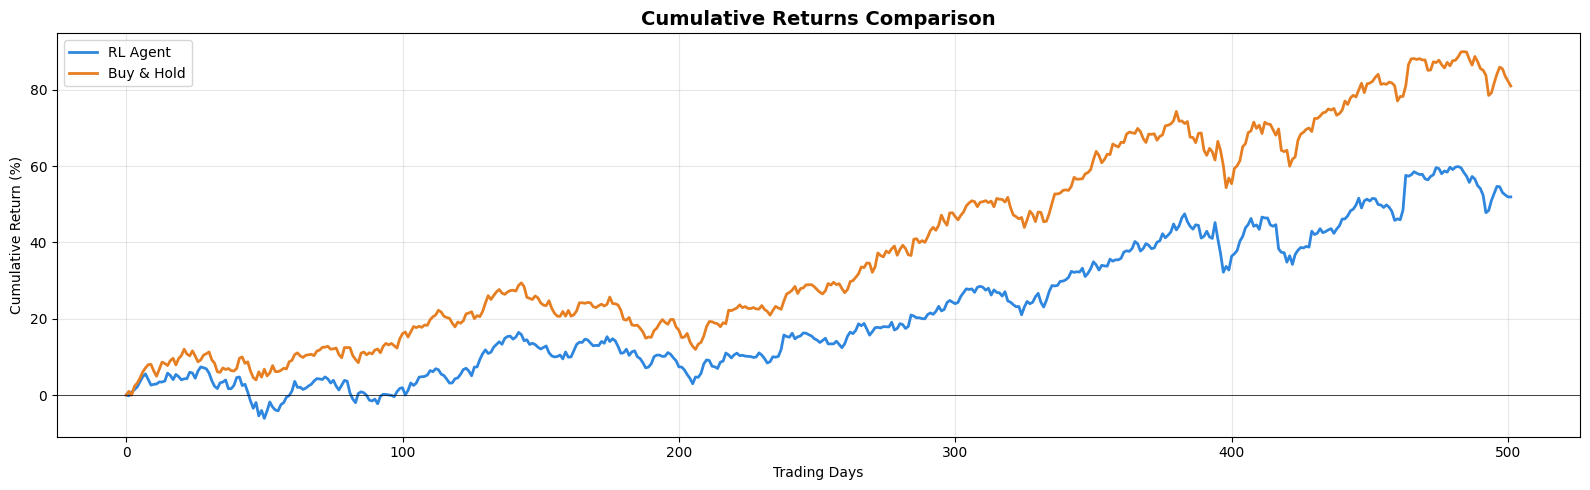


                    BENCHMARK COMPARISON                    
Metric                           RL Agent      Buy & Hold
------------------------------------------------------------
Total Return (%)                    51.91           80.96
Sharpe Ratio                         1.31            1.90
Volatility (%)                      17.18           16.39
Saved: ./FinRL_Trading_Results/plots/cumulative_returns_comparison.png


In [36]:
# Plot 3: Cumulative Returns Comparison
portfolio_cum_ret = [(v / INITIAL_AMOUNT - 1) * 100 for v in portfolio_aligned]
benchmark_cum_ret = [(v / INITIAL_AMOUNT - 1) * 100 for v in benchmark_aligned]

plt.figure(figsize=(16, 5))
plt.plot(portfolio_cum_ret, linewidth=2, color='#2E86DE', label='RL Agent')
plt.plot(benchmark_cum_ret, linewidth=2, color='#E67E22', label='Buy & Hold')
plt.axhline(y=0, color='black', linewidth=0.5)
plt.title('Cumulative Returns Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Trading Days')
plt.ylabel('Cumulative Return (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/plots/cumulative_returns_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Print comparison metrics
benchmark_return = (benchmark_aligned[-1] - INITIAL_AMOUNT) / INITIAL_AMOUNT * 100
benchmark_returns_series = pd.Series(benchmark_aligned).pct_change().dropna()
benchmark_sharpe = benchmark_returns_series.mean() / benchmark_returns_series.std() * np.sqrt(252) if benchmark_returns_series.std() != 0 else 0
benchmark_vol = benchmark_returns_series.std() * np.sqrt(252) * 100

print(f"\n{'='*60}")
print(f"{'BENCHMARK COMPARISON':^60}")
print(f"{'='*60}")
print(f"{'Metric':<25} {'RL Agent':>15} {'Buy & Hold':>15}")
print(f"{'-'*60}")
print(f"{'Total Return (%)':<25} {total_return:>15.2f} {benchmark_return:>15.2f}")
print(f"{'Sharpe Ratio':<25} {sharpe_ratio:>15.2f} {benchmark_sharpe:>15.2f}")
print(f"{'Volatility (%)':<25} {volatility:>15.2f} {benchmark_vol:>15.2f}")
print(f"{'='*60}")
print(f"Saved: {PROJECT_PATH}/plots/cumulative_returns_comparison.png")

# Individual Stock Analysis

Analyze performance attribution and trading activity for each stock in the portfolio.

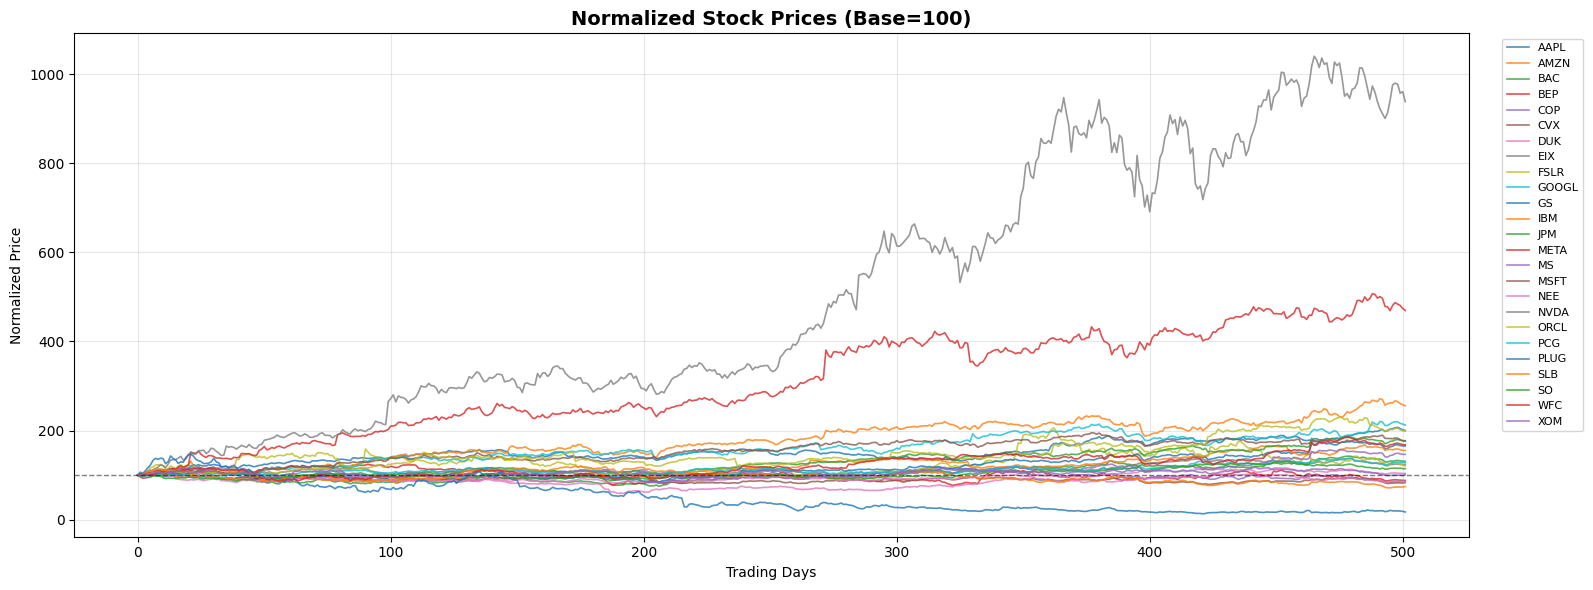

Saved: ./FinRL_Trading_Results/plots/normalized_prices.png


In [37]:
# Individual stock price movements during test period
test_prices = test_df.pivot(index='date', columns='tic', values='close').dropna()
n_trading_days = min(len(account_values), len(test_prices))

# Normalized stock prices
normalized_prices = test_prices.copy()
for col in normalized_prices.columns:
    normalized_prices[col] = normalized_prices[col] / normalized_prices[col].iloc[0] * 100

# --- FIX: Use the actual available tickers for plotting ---
# Get the list of tickers that survived the data cleaning (dropna())
actual_tickers_for_plot = normalized_prices.columns.tolist()

# Plot 1: Normalized Stock Prices (full width)
plt.figure(figsize=(16, 6))

# Plot only the tickers that are available in the DataFrame
for ticker in actual_tickers_for_plot:
    plt.plot(normalized_prices[ticker].values[:n_trading_days], linewidth=1.2, label=ticker, alpha=0.8)

plt.axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.title('Normalized Stock Prices (Base=100)', fontsize=14, fontweight='bold')
plt.xlabel('Trading Days')
plt.ylabel('Normalized Price')
# Adjust legend column count based on the actual number of tickers
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=max(1, len(actual_tickers_for_plot)//15))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/plots/normalized_prices.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {PROJECT_PATH}/plots/normalized_prices.png")

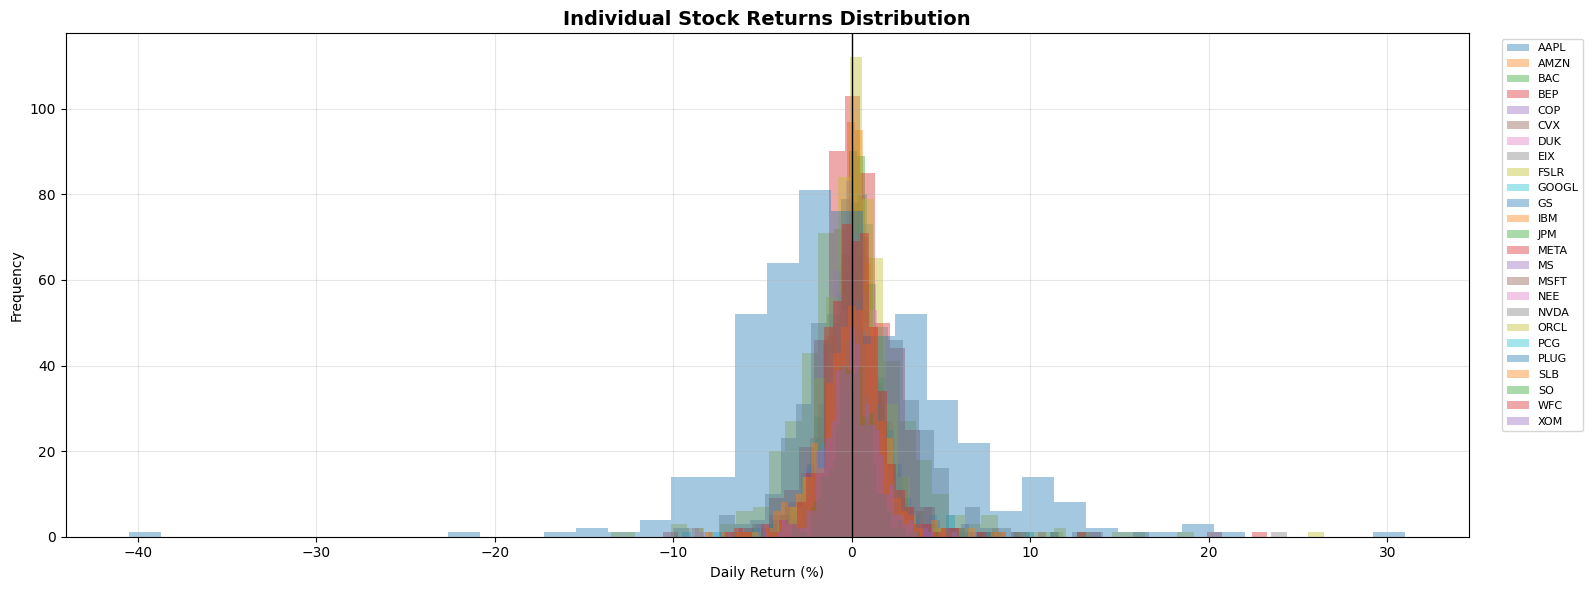

Saved: ./FinRL_Trading_Results/plots/stock_returns_dist.png


In [38]:
# Plot 2: Individual Stock Returns Distribution (full width)
test_prices = test_df.pivot(index='date', columns='tic', values='close').dropna() # Re-create test_prices if not already done
stock_returns = test_prices.pct_change().dropna()

# --- FIX: Use the actual available tickers for plotting ---
# Get the list of tickers that survived the data cleaning
actual_tickers_for_plot = stock_returns.columns.tolist()

plt.figure(figsize=(16, 6))

# Plot only the tickers that are available in the DataFrame
for ticker in actual_tickers_for_plot:
    plt.hist(stock_returns[ticker] * 100, bins=40, alpha=0.4, label=ticker)

plt.axvline(x=0, color='black', linewidth=1)
plt.title('Individual Stock Returns Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
# Adjust legend column count based on the actual number of tickers
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=max(1, len(actual_tickers_for_plot)//15))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/plots/stock_returns_dist.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {PROJECT_PATH}/plots/stock_returns_dist.png")

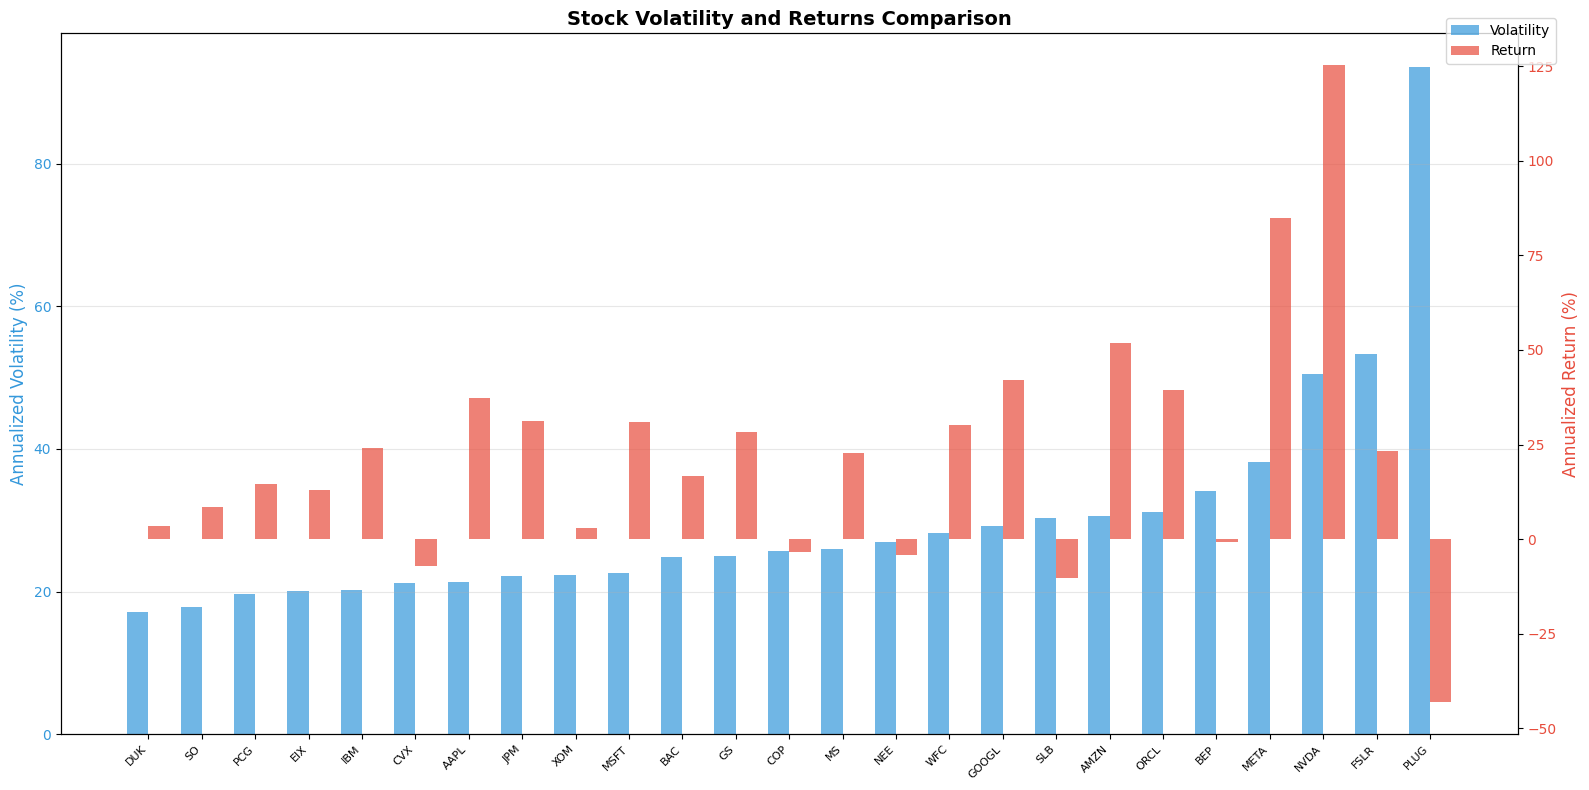

Saved: ./FinRL_Trading_Results/plots/stock_vol_returns.png


In [39]:
# Plot 3: Stock Volatility and Returns Comparison (full width bar chart)
stock_vol = stock_returns.std() * np.sqrt(252) * 100
stock_ret = stock_returns.mean() * 252 * 100

# Sort by volatility for better visualization
sorted_idx = stock_vol.sort_values(ascending=True).index

fig, ax1 = plt.subplots(figsize=(16, 8))
x = np.arange(len(sorted_idx))
width = 0.4

bars1 = ax1.bar(x - width/2, stock_vol[sorted_idx], width, color='#3498DB', alpha=0.7, label='Volatility')
ax1.set_ylabel('Annualized Volatility (%)', color='#3498DB', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#3498DB')

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, stock_ret[sorted_idx], width, color='#E74C3C', alpha=0.7, label='Return')
ax2.set_ylabel('Annualized Return (%)', color='#E74C3C', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#E74C3C')

ax1.set_xticks(x)
ax1.set_xticklabels(sorted_idx, rotation=45, ha='right', fontsize=8)
ax1.set_title('Stock Volatility and Returns Comparison', fontsize=14, fontweight='bold')
ax1.axhline(y=0, color='black', linewidth=0.5)
ax1.grid(True, alpha=0.3, axis='y')

fig.legend(loc='upper right', bbox_to_anchor=(0.98, 0.98))
plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/plots/stock_vol_returns.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {PROJECT_PATH}/plots/stock_vol_returns.png")

# Sector Distribution Analysis

Pie chart showing portfolio composition by sector/industry.

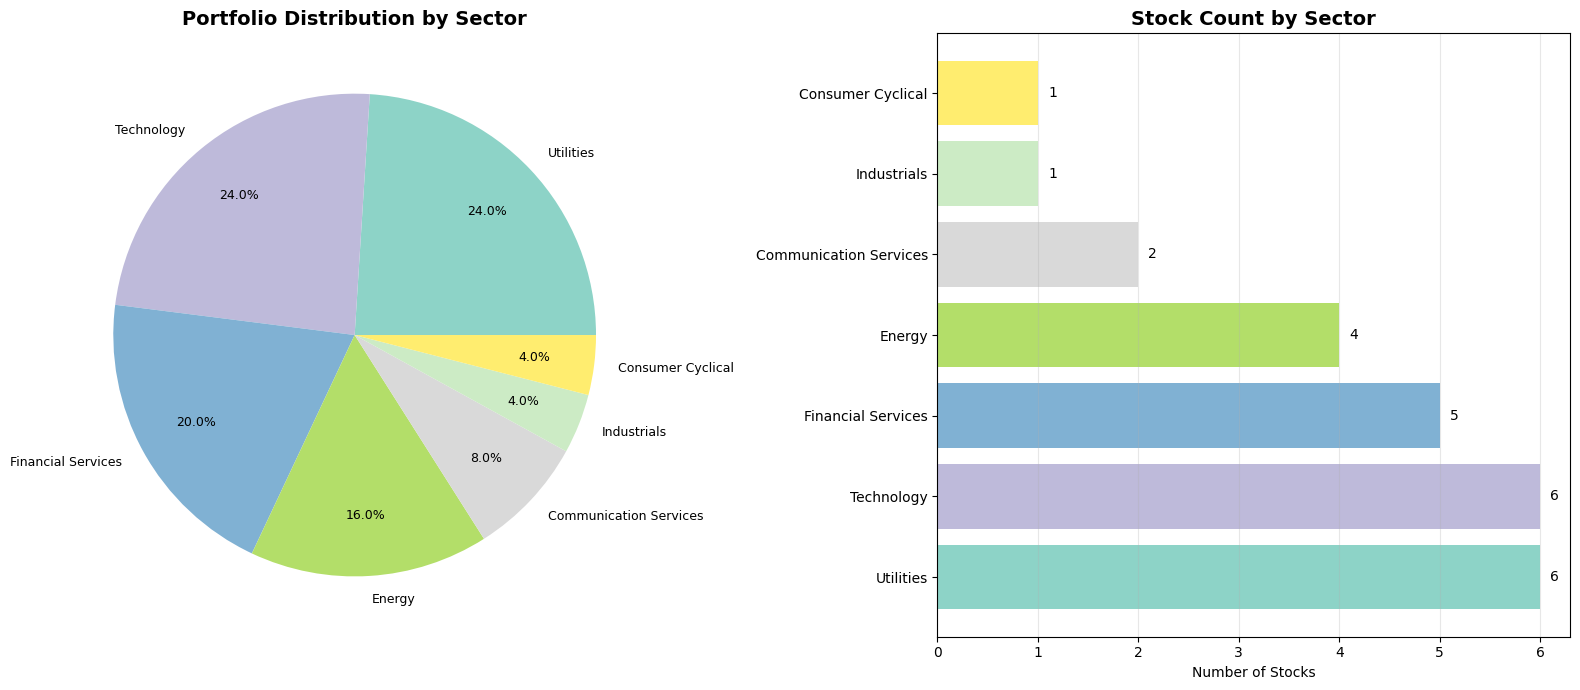

Saved: ./FinRL_Trading_Results/plots/sector_distribution.png

                 SECTOR BREAKDOWN                 
Utilities                        6 stocks ( 24.0%)
Technology                       6 stocks ( 24.0%)
Financial Services               5 stocks ( 20.0%)
Energy                           4 stocks ( 16.0%)
Communication Services           2 stocks (  8.0%)
Industrials                      1 stocks (  4.0%)
Consumer Cyclical                1 stocks (  4.0%)


In [40]:
# Fetch sector information for each ticker
sector_info = {}
for ticker in TICKER_LIST:
    try:
        stock = yf.Ticker(ticker)
        info = stock.info
        sector = info.get('sector', 'Unknown')
        sector_info[ticker] = sector
    except:
        sector_info[ticker] = 'Unknown'

# Count stocks per sector
sector_counts = pd.Series(sector_info).value_counts()

# Create pie chart
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Pie chart
colors = plt.cm.Set3(np.linspace(0, 1, len(sector_counts)))
wedges, texts, autotexts = axes[0].pie(sector_counts.values, labels=sector_counts.index,
                                        autopct='%1.1f%%', colors=colors,
                                        pctdistance=0.75, labeldistance=1.1)
axes[0].set_title('Portfolio Distribution by Sector', fontsize=14, fontweight='bold')
for autotext in autotexts:
    autotext.set_fontsize(9)
for text in texts:
    text.set_fontsize(9)

# Bar chart for sector counts
axes[1].barh(sector_counts.index, sector_counts.values, color=colors)
axes[1].set_xlabel('Number of Stocks')
axes[1].set_title('Stock Count by Sector', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(sector_counts.values):
    axes[1].text(v + 0.1, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/plots/sector_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {PROJECT_PATH}/plots/sector_distribution.png")

# Print sector breakdown
print(f"\n{'='*50}")
print(f"{'SECTOR BREAKDOWN':^50}")
print(f"{'='*50}")
for sector, count in sector_counts.items():
    pct = count / len(TICKER_LIST) * 100
    print(f"{sector:<30} {count:>3} stocks ({pct:>5.1f}%)")
print(f"{'='*50}")

# Trading Activity Analysis

Visualize the agent's trading behavior, position sizes, and action patterns over time.

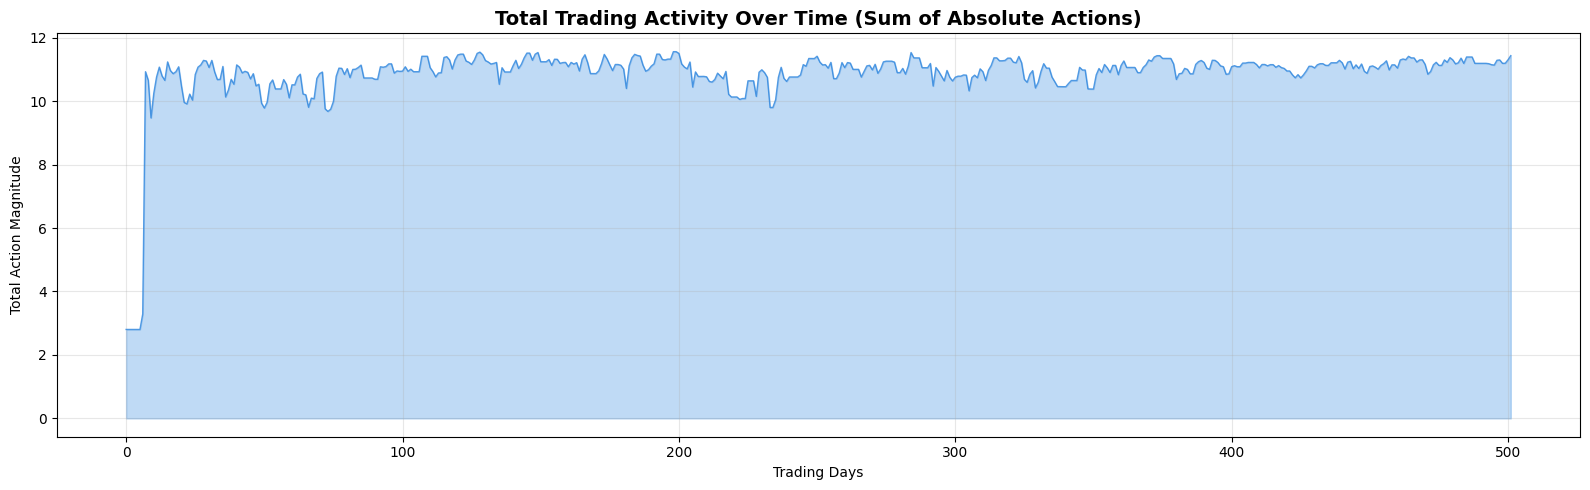

Saved: ./FinRL_Trading_Results/plots/total_trading_activity.png


In [41]:
actions_array = np.array(actions_taken)
states_array = np.array(states_log)

# Plot 1: Total Trading Activity Over Time (aggregated)
plt.figure(figsize=(16, 5))
if actions_array.ndim > 1:
    total_action = np.sum(np.abs(actions_array), axis=1)
else:
    total_action = np.abs(actions_array)
plt.plot(total_action, linewidth=1, color='#2E86DE', alpha=0.8)
plt.fill_between(range(len(total_action)), 0, total_action, alpha=0.3, color='#2E86DE')
plt.title('Total Trading Activity Over Time (Sum of Absolute Actions)', fontsize=14, fontweight='bold')
plt.xlabel('Trading Days')
plt.ylabel('Total Action Magnitude')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/plots/total_trading_activity.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {PROJECT_PATH}/plots/total_trading_activity.png")

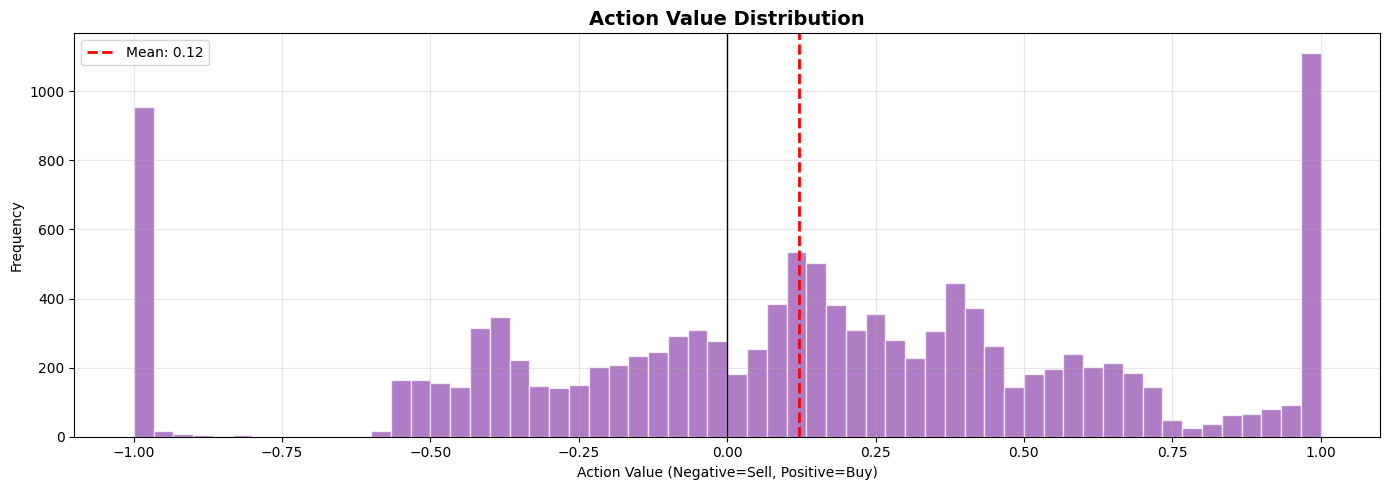

Saved: ./FinRL_Trading_Results/plots/action_distribution.png


In [42]:
# Plot 2: Action Magnitude Distribution
plt.figure(figsize=(14, 5))
if actions_array.ndim > 1:
    action_magnitudes = actions_array.flatten()
else:
    action_magnitudes = actions_array
plt.hist(action_magnitudes, bins=60, color='#8E44AD', edgecolor='white', alpha=0.7)
plt.axvline(x=0, color='black', linewidth=1)
plt.axvline(x=np.mean(action_magnitudes), color='red', linestyle='--',
            linewidth=2, label=f'Mean: {np.mean(action_magnitudes):.2f}')
plt.title('Action Value Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Action Value (Negative=Sell, Positive=Buy)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/plots/action_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {PROJECT_PATH}/plots/action_distribution.png")

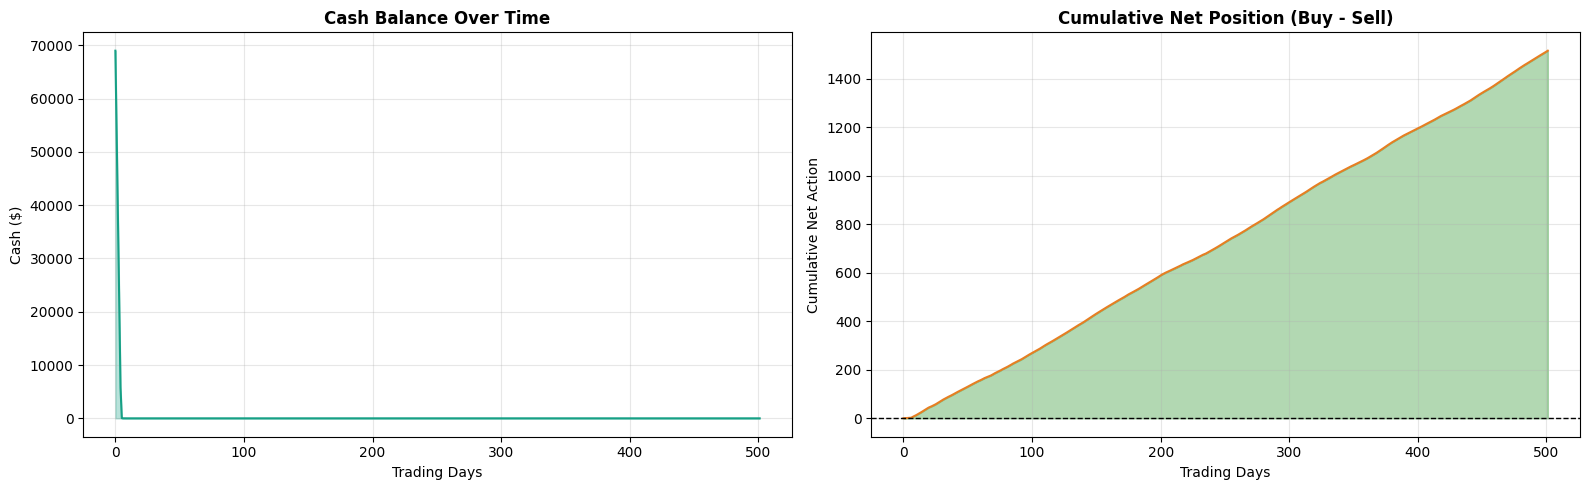

Saved: ./FinRL_Trading_Results/plots/balance_position.png


In [43]:
# Plot 3: Cash Balance and Net Position Over Time
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Cash balance
if states_array.ndim > 1 and states_array.shape[1] > 0:
    balance = states_array[:, 0]
    axes[0].plot(balance, linewidth=1.5, color='#16A085')
    axes[0].fill_between(range(len(balance)), balance.min(), balance, alpha=0.3, color='#16A085')
    axes[0].set_title('Cash Balance Over Time', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Trading Days')
    axes[0].set_ylabel('Cash ($)')
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'State data not available', ha='center', va='center', fontsize=14)

# Net position (buy vs sell pressure)
if actions_array.ndim > 1:
    net_action = np.sum(actions_array, axis=1)
    cumulative_net = np.cumsum(net_action)
else:
    net_action = actions_array
    cumulative_net = np.cumsum(net_action)

axes[1].plot(cumulative_net, linewidth=1.5, color='#E67E22')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].fill_between(range(len(cumulative_net)), 0, cumulative_net,
                     where=cumulative_net >= 0, alpha=0.3, color='green')
axes[1].fill_between(range(len(cumulative_net)), 0, cumulative_net,
                     where=cumulative_net < 0, alpha=0.3, color='red')
axes[1].set_title('Cumulative Net Position (Buy - Sell)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Trading Days')
axes[1].set_ylabel('Cumulative Net Action')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/plots/balance_position.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {PROJECT_PATH}/plots/balance_position.png")

# SHAP Explainability Analysis

Use SHAP (SHapley Additive exPlanations) to understand which features drive the agent's trading decisions.

In [44]:
states_array = np.array(states_log)

def predict_action(states):
    actions = []
    for state in states:
        action, _ = model.predict(state.reshape(1, -1), deterministic=True)
        actions.append(action[0])
    return np.array(actions)

sample_size = min(100, len(states_array))
background_data = states_array[:sample_size]
test_data = states_array[sample_size:sample_size+30]

feature_names = ['balance'] + \
    [f'{t}_shares' for t in TICKER_LIST] + \
    [f'{t}_price' for t in TICKER_LIST] + \
    [f'{t}_{ind}' for t in TICKER_LIST for ind in INDICATORS_LIST]
feature_names = feature_names[:states_array.shape[1]]

print(f"Computing SHAP values for {len(test_data)} samples...")
explainer = shap.KernelExplainer(predict_action, background_data)
shap_values = explainer.shap_values(test_data)
print("✓ SHAP analysis complete")

Computing SHAP values for 30 samples...


100%|██████████| 30/30 [29:00<00:00, 58.02s/it] 

✓ SHAP analysis complete


# SHAP Visualization

Generate summary plots, feature importance charts, and decision breakdowns.

Original SHAP shape: (30, 201, 25)
Processed SHAP shape: (30, 201)


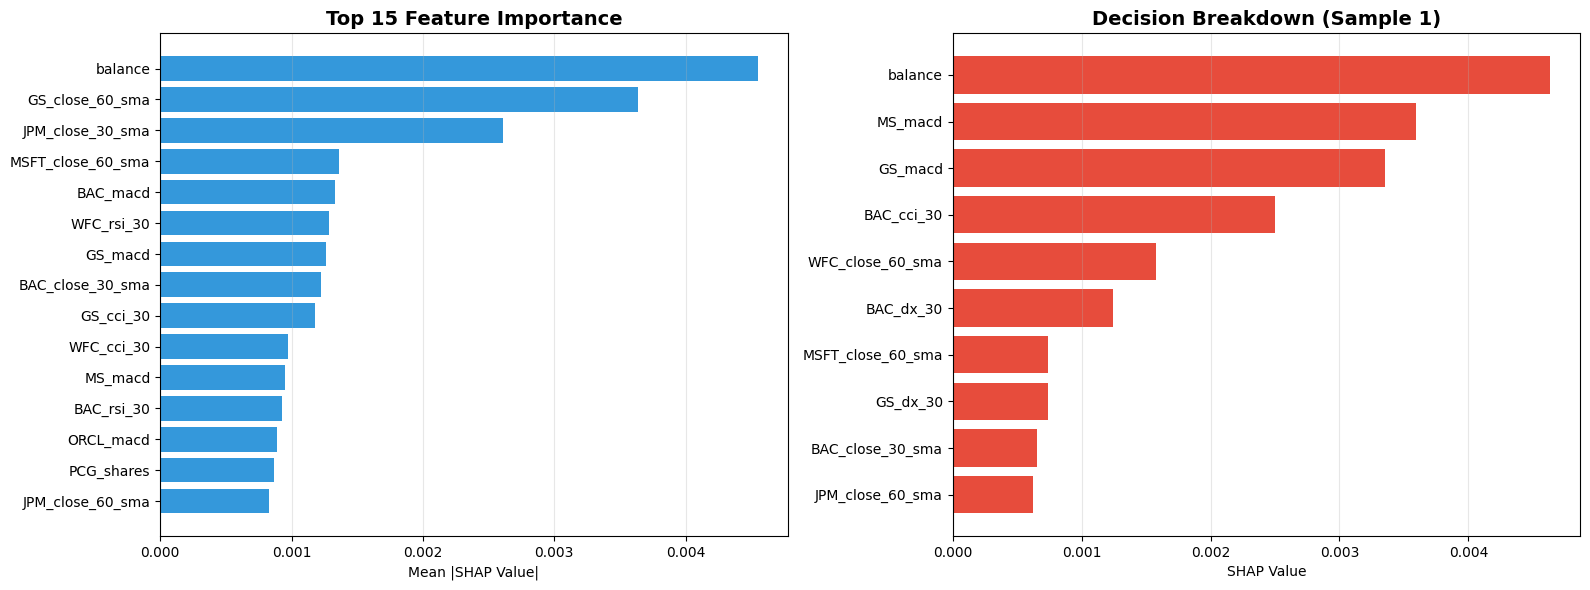

Saved: ./FinRL_Trading_Results/plots/shap_analysis.png


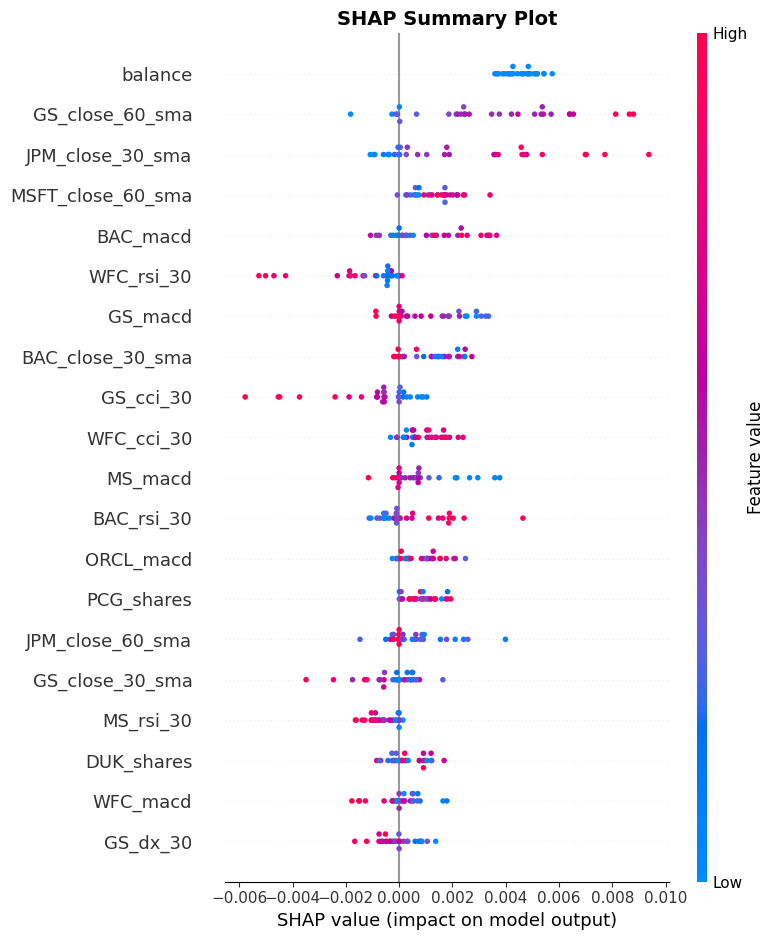

Saved: ./FinRL_Trading_Results/plots/shap_summary.png


In [45]:
test_data_df = pd.DataFrame(test_data, columns=feature_names)
shap_values_clean = shap_values[0] if isinstance(shap_values, list) else shap_values
base_value_clean = explainer.expected_value[0] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

# Handle multi-dimensional SHAP values (for multi-action output)
print(f"Original SHAP shape: {np.shape(shap_values_clean)}")

if len(np.shape(shap_values_clean)) == 3:
    shap_values_clean = np.mean(shap_values_clean, axis=(1, 2)) if shap_values_clean.shape[1] > 1 else np.squeeze(shap_values_clean)

    if len(np.shape(shap_values_clean)) != 2:
        original_shape = np.shape(shap_values)
        if isinstance(shap_values, list):
            shap_values_clean = np.array(shap_values[0])
        else:
            shap_values_clean = np.array(shap_values)

        while len(shap_values_clean.shape) > 2:
            shap_values_clean = np.mean(shap_values_clean, axis=-1)

print(f"Processed SHAP shape: {np.shape(shap_values_clean)}")

if len(shap_values_clean.shape) == 1:
    shap_values_clean = shap_values_clean.reshape(1, -1)

n_features = shap_values_clean.shape[-1] if len(shap_values_clean.shape) > 1 else len(shap_values_clean)
feature_names_plot = feature_names[:n_features] if n_features <= len(feature_names) else feature_names + [f'feature_{i}' for i in range(len(feature_names), n_features)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature Importance Bar Chart
if len(shap_values_clean.shape) == 2:
    mean_abs_shap = np.abs(shap_values_clean).mean(axis=0)
else:
    mean_abs_shap = np.abs(shap_values_clean)

n_top = min(15, len(mean_abs_shap))
sorted_idx = np.argsort(mean_abs_shap)[-n_top:]

axes[0].barh(range(len(sorted_idx)), mean_abs_shap[sorted_idx], color='#3498DB')
axes[0].set_yticks(range(len(sorted_idx)))
axes[0].set_yticklabels([feature_names_plot[i] if i < len(feature_names_plot) else f'feat_{i}' for i in sorted_idx])
axes[0].set_xlabel('Mean |SHAP Value|')
axes[0].set_title(f'Top {n_top} Feature Importance', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Waterfall for single prediction
row_idx = 0
if len(shap_values_clean.shape) == 2:
    shap_row = shap_values_clean[row_idx]
else:
    shap_row = shap_values_clean

n_top_waterfall = min(10, len(shap_row))
sorted_features = np.argsort(np.abs(shap_row))[-n_top_waterfall:]
colors = ['#E74C3C' if v > 0 else '#3498DB' for v in shap_row[sorted_features]]

axes[1].barh(range(len(sorted_features)), shap_row[sorted_features], color=colors)
axes[1].set_yticks(range(len(sorted_features)))
axes[1].set_yticklabels([feature_names_plot[i] if i < len(feature_names_plot) else f'feat_{i}' for i in sorted_features])
axes[1].axvline(x=0, color='black', linewidth=0.5)
axes[1].set_xlabel('SHAP Value')
axes[1].set_title('Decision Breakdown (Sample 1)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/plots/shap_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {PROJECT_PATH}/plots/shap_analysis.png")

# SHAP Summary Plot
if len(shap_values_clean.shape) == 2 and shap_values_clean.shape[1] == len(feature_names_plot):
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_clean, test_data_df[feature_names_plot[:shap_values_clean.shape[1]]],
                      feature_names=feature_names_plot[:shap_values_clean.shape[1]], show=False)
    plt.title('SHAP Summary Plot', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{PROJECT_PATH}/plots/shap_summary.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved: {PROJECT_PATH}/plots/shap_summary.png")
else:
    print("SHAP summary plot skipped due to shape mismatch")

# Key Insights and Save SHAP Checkpoint

Summarize the most influential features and save SHAP analysis results locally.

In [46]:
import pickle

mean_abs_shap = np.abs(shap_values_clean).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[-10:][::-1]

print(f"\n{'='*60}")
print(f"{'TOP 10 FEATURES DRIVING TRADING DECISIONS':^60}")
print(f"{'='*60}")
for i, idx in enumerate(top_idx, 1):
    print(f"{i:2d}. {feature_names[idx]:35s} Impact: {mean_abs_shap[idx]:.4f}")
print(f"{'='*60}")

print("\nSHAP INTERPRETATION GUIDE:")
print("-" * 40)
print("- Higher SHAP value: Feature pushes action UP (buy)")
print("- Lower SHAP value: Feature pushes action DOWN (sell)")
print("- Red in summary: High feature value")
print("- Blue in summary: Low feature value")

# Save SHAP checkpoint locally
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
shap_checkpoint = {
    'shap_values': shap_values_clean,
    'feature_names': feature_names,
    'test_data': test_data,
    'base_value': base_value_clean,
    'mean_abs_shap': mean_abs_shap
}
shap_checkpoint_path = f"{PROJECT_PATH}/checkpoints/shap_analysis_{timestamp}.pkl"
with open(shap_checkpoint_path, 'wb') as f:
    pickle.dump(shap_checkpoint, f)

print(f"\nSHAP checkpoint saved: {shap_checkpoint_path}")


         TOP 10 FEATURES DRIVING TRADING DECISIONS          
 1. balance                             Impact: 0.0045
 2. GS_close_60_sma                     Impact: 0.0036
 3. JPM_close_30_sma                    Impact: 0.0026
 4. MSFT_close_60_sma                   Impact: 0.0014
 5. BAC_macd                            Impact: 0.0013
 6. WFC_rsi_30                          Impact: 0.0013
 7. GS_macd                             Impact: 0.0013
 8. BAC_close_30_sma                    Impact: 0.0012
 9. GS_cci_30                           Impact: 0.0012
10. WFC_cci_30                          Impact: 0.0010

SHAP INTERPRETATION GUIDE:
----------------------------------------
- Higher SHAP value: Feature pushes action UP (buy)
- Lower SHAP value: Feature pushes action DOWN (sell)
- Red in summary: High feature value
- Blue in summary: Low feature value

SHAP checkpoint saved: ./FinRL_Trading_Results/checkpoints/shap_analysis_20251206_014359.pkl


# Save Model and Results

Export the trained model and performance metrics locally.

In [47]:
# Save final model locally
model.save(f"{PROJECT_PATH}/trained_ppo_trading_model")

# Save performance metrics
results_df = pd.DataFrame({
    'Metric': ['Initial Value', 'Final Value', 'Total Return (%)',
               'Sharpe Ratio', 'Max Drawdown (%)', 'Volatility (%)', 'Win Rate (%)'],
    'Value': [initial_value, final_value, total_return, sharpe_ratio, max_drawdown, volatility, win_rate]
})
results_df.to_csv(f'{PROJECT_PATH}/backtest_results.csv', index=False)

# Save account values for later analysis
np.save(f'{PROJECT_PATH}/checkpoints/account_values.npy', np.array(account_values))
np.save(f'{PROJECT_PATH}/checkpoints/actions_taken.npy', np.array(actions_taken))

print(f"\n{'='*60}")
print(f"{'ALL FILES SAVED LOCALLY':^60}")
print(f"{'='*60}")
print(f"Location: {PROJECT_PATH}")
print("\nModels:")
print("   - trained_ppo_trading_model.zip")
print("   - checkpoints/ppo_model_trained_*.zip")
print("\nData:")
print("   - backtest_results.csv")
print("   - checkpoints/account_values.npy")
print("   - checkpoints/actions_taken.npy")
print("   - checkpoints/shap_analysis_*.pkl")
print("\nPlots:")
print("   - plots/portfolio_performance.png")
print("   - plots/shap_analysis.png")
print("   - plots/shap_summary.png")
print("   - plots/rolling_sharpe.png")
print("   - plots/rolling_volatility.png")
print("   - plots/periodic_var.png")
print("   - plots/underwater.png")
print("   - plots/portfolio_vs_benchmark.png")
print("   - plots/relative_performance.png")
print("   - plots/cumulative_returns_comparison.png")
print("   - plots/normalized_prices.png")
print("   - plots/stock_returns_dist.png")
print("   - plots/stock_vol_returns.png")
print("   - plots/sector_distribution.png")
print("   - plots/total_trading_activity.png")
print("   - plots/action_distribution.png")
print("   - plots/balance_position.png")
print(f"{'='*60}")


                  ALL FILES SAVED LOCALLY                   
Location: ./FinRL_Trading_Results

Models:
   - trained_ppo_trading_model.zip
   - checkpoints/ppo_model_trained_*.zip

Data:
   - backtest_results.csv
   - checkpoints/account_values.npy
   - checkpoints/actions_taken.npy
   - checkpoints/shap_analysis_*.pkl

Plots:
   - plots/portfolio_performance.png
   - plots/shap_analysis.png
   - plots/shap_summary.png
   - plots/rolling_sharpe.png
   - plots/rolling_volatility.png
   - plots/periodic_var.png
   - plots/underwater.png
   - plots/portfolio_vs_benchmark.png
   - plots/relative_performance.png
   - plots/cumulative_returns_comparison.png
   - plots/normalized_prices.png
   - plots/stock_returns_dist.png
   - plots/stock_vol_returns.png
   - plots/sector_distribution.png
   - plots/total_trading_activity.png
   - plots/action_distribution.png
   - plots/balance_position.png
